In [2]:
pip install --upgrade osmnx

Note: you may need to restart the kernel to use updated packages.


In [4]:
# For OSMnx >= 1.0
import osmnx as ox
ox.settings.log_console = True
ox.settings.use_cache = True

In [6]:
pip install osmnx==1.0.0  # or any other version

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.1/541.1 kB 11.8 MB/s eta 0:00:00
  Attempting uninstall: osmnx
    Found existing installation: osmnx 2.0.5
    Uninstalling osmnx-2.0.5:
      Successfully uninstalled osmnx-2.0.5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [osmnx]32m2/3 [osmnx]
Note: you may need to restart the kernel to use updated packages.


Geocoding landmarks...
Found: Times Square, Manhattan, NY
Found: Empire State Building, Manhattan, NY
Found: Central Park, Manhattan, NY
Found: One World Trade Center, Manhattan, NY
Found: Rockefeller Center, Manhattan, NY
Found: Washington Square Park, Manhattan, NY
Found: Brooklyn Bridge, Manhattan, NY
Found: The High Line, Manhattan, NY

Processing graph...
Graph has 37519 nodes and 120660 edges

Snapping landmarks to network...

Computing distances...

Creating visualizations...


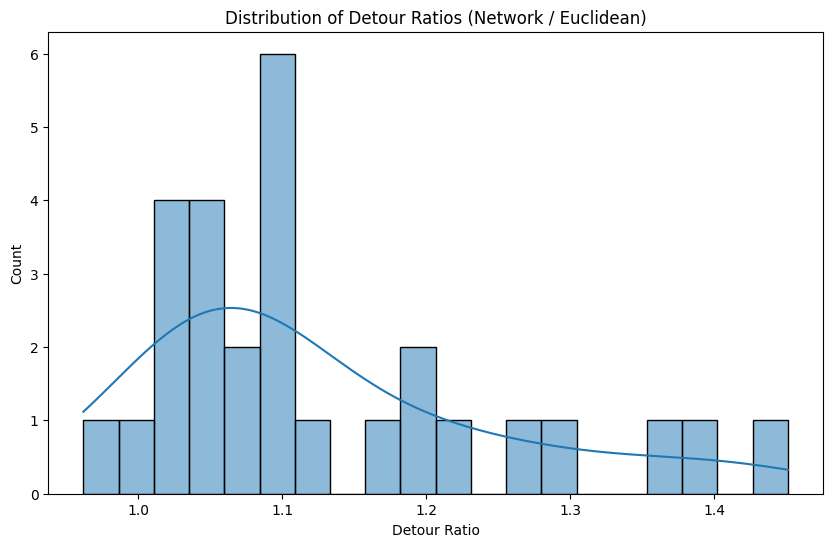

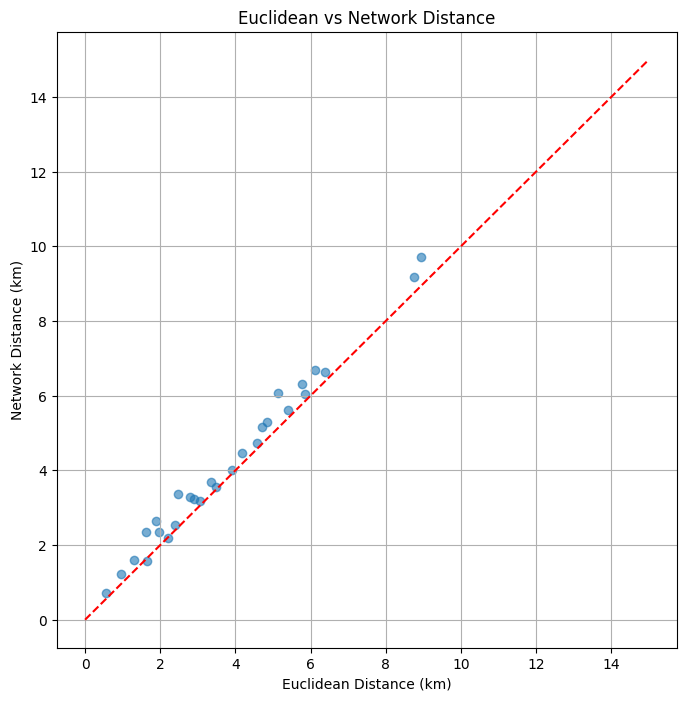


Analyzing network...

Network Metrics:
n_nodes: 37519.0000
n_edges: 120660.0000
avg_node_degree: 6.4319
density: 0.0001
n_components: 1.0000
avg_detour_ratio: 1.1291
median_detour_ratio: 1.0940
pct_detour_gt_1.25: 17.8571

Saving results...
Analysis complete!


In [15]:
# %% [markdown]
# # Manhattan Landmarks — Network vs Euclidean Distance
# 
# **Research statement:**
# We will define a pedestrian street network for Manhattan, identify a set of well-known landmarks as nodes, and compare Euclidean (straight-line) distances to network distances between them.

# %%
# ## Imports
import os
import osmnx as ox
import geopandas as gpd
import pandas as pd
import numpy as np
import networkx as nx
from shapely.geometry import Point, LineString
import matplotlib.pyplot as plt
import seaborn as sns
from functools import partial
import math
from geopy.geocoders import Nominatim

# Configure OSMnx
ox.settings.log_console = True
ox.settings.use_cache = True
ox.settings.timeout = 180

# Define landmarks
landmarks = [
    "Times Square, Manhattan, NY",
    "Empire State Building, Manhattan, NY",
    "Central Park, Manhattan, NY",
    "One World Trade Center, Manhattan, NY",
    "Rockefeller Center, Manhattan, NY",
    "Washington Square Park, Manhattan, NY",
    "Brooklyn Bridge, Manhattan, NY",
    "The High Line, Manhattan, NY"
]

# Create a GeoDataFrame for landmarks
print("Geocoding landmarks...")
geolocator = Nominatim(user_agent="manhattan_landmarks")
landmark_data = []

for landmark in landmarks:
    try:
        location = geolocator.geocode(landmark)
        if location:
            landmark_data.append({
                'name': landmark,
                'geometry': Point(location.longitude, location.latitude)
            })
            print(f"Found: {landmark}")
        else:
            print(f"Could not find: {landmark}")
    except Exception as e:
        print(f"Error geocoding {landmark}: {e}")

landmarks_gdf = gpd.GeoDataFrame(landmark_data, crs="EPSG:4326")

# %%
# Get Manhattan street network
print("\nDownloading Manhattan street network...")
place_name = "Manhattan, New York, USA"

# Use a bounding box approach instead of place name for more reliable results
# Alternative approach using place name
G = ox.graph_from_place("Manhattan, New York, USA", network_type='walk')

# Simplify and project
print("Processing graph...")
if not G.graph.get('simplified', False):
    G = ox.simplify_graph(G)
    
# Project to UTM
G_proj = ox.project_graph(G)

# Get nodes and edges as GeoDataFrames
nodes, edges = ox.graph_to_gdfs(G_proj, nodes=True, edges=True)
print(f"Graph has {len(nodes)} nodes and {len(edges)} edges")

# %%
# Snap landmarks to nearest network nodes
print("\nSnapping landmarks to network...")
landmarks_proj = landmarks_gdf.to_crs(nodes.crs)

def nearest_node_id(point_geom, G, nodes_gdf):
    x, y = point_geom.x, point_geom.y
    return ox.distance.nearest_nodes(G, x, y)

landmarks_proj['node'] = landmarks_proj.geometry.apply(
    lambda p: nearest_node_id(p, G_proj, nodes)
)

# %%
# Compute distances
print("\nComputing distances...")
from math import radians, cos, sin, asin, sqrt

def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return 2 * asin(sqrt(a)) * 6371000  # Earth radius in meters

# Create pairwise distance matrix
rows = []
n = len(landmarks_proj)

for i in range(n):
    for j in range(i+1, n):
        a = landmarks_gdf.geometry.iloc[i]
        b = landmarks_gdf.geometry.iloc[j]
        
        # Euclidean distance
        eu_m = haversine(a.x, a.y, b.x, b.y)
        
        # Network distance
        source = int(landmarks_proj.node.iloc[i])
        target = int(landmarks_proj.node.iloc[j])
        
        try:
            net_m = nx.shortest_path_length(G_proj, source=source, target=target, weight='length')
            net_over_eu = net_m / eu_m
        except (nx.NetworkXNoPath, nx.NodeNotFound):
            net_m = np.nan
            net_over_eu = np.nan
            
        rows.append({
            'a': landmarks_proj.name.iloc[i],
            'b': landmarks_proj.name.iloc[j],
            'eu_m': eu_m,
            'net_m': net_m,
            'net_over_eu': net_over_eu
        })

pairs_df = pd.DataFrame(rows)
pairs_df['eu_km'] = pairs_df['eu_m'] / 1000
pairs_df['net_km'] = pairs_df['net_m'] / 1000
pairs_df = pairs_df[['a', 'b', 'eu_km', 'net_km', 'net_over_eu']].sort_values('net_over_eu', ascending=False)
pairs_df.head()

# %%
# Visualizations
print("\nCreating visualizations...")
plt.figure(figsize=(10, 6))
sns.histplot(pairs_df['net_over_eu'].dropna(), bins=20, kde=True)
plt.title('Distribution of Detour Ratios (Network / Euclidean)')
plt.xlabel('Detour Ratio')
plt.ylabel('Count')
plt.show()

# Scatter plot
plt.figure(figsize=(8, 8))
plt.scatter(pairs_df['eu_km'], pairs_df['net_km'], alpha=0.6)
plt.plot([0, 15], [0, 15], 'r--')  # 1:1 line
plt.xlabel('Euclidean Distance (km)')
plt.ylabel('Network Distance (km)')
plt.title('Euclidean vs Network Distance')
plt.grid(True)
plt.show()

# %%
# Network Analysis
print("\nAnalyzing network...")
# Get largest connected component
G_undir = G_proj.to_undirected()
largest_cc = max(nx.connected_components(G_undir), key=len)
G_lcc = G_undir.subgraph(largest_cc).copy()

# Basic metrics
metrics = {
    'n_nodes': G_proj.number_of_nodes(),
    'n_edges': G_proj.number_of_edges(),
    'avg_node_degree': sum(dict(G_proj.degree()).values()) / G_proj.number_of_nodes(),
    'density': nx.density(G_proj),
    'n_components': nx.number_weakly_connected_components(G_proj),
    'avg_detour_ratio': pairs_df['net_over_eu'].mean(),
    'median_detour_ratio': pairs_df['net_over_eu'].median(),
    'pct_detour_gt_1.25': (pairs_df['net_over_eu'] > 1.25).mean() * 100
}

# Display metrics
print("\nNetwork Metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

# %%
# Save results
print("\nSaving results...")
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)

# Save dataframes
pairs_df.to_csv(os.path.join(output_dir, "landmark_distances.csv"), index=False)
landmarks_gdf.to_file(os.path.join(output_dir, "landmarks.geojson"), driver="GeoJSON")
ox.save_graph_geopackage(G_proj, filepath=os.path.join(output_dir, "manhattan_network.gpkg"))

print("Analysis complete!")